# Python en 30 minutos: leer datos sin convertirse en programador

**Caso:** La velocidad de las frutas  
**Nivel:** primera lectura de código  
**Datos:** 500 registros sintéticos; ninguna persona real

Este cuaderno no intenta enseñarle a escribir programas desde cero. Su meta es más
concreta: que pueda **leer una operación**, reconocer qué columna utiliza, ejecutar
la celda y realizar cambios pequeños sin alterar el diseño del estudio.

Al terminar podrá:

1. cargar un CSV con `pandas`;
2. reconocer filas y columnas;
3. filtrar observaciones mediante una regla ya fijada;
4. calcular medias por grupo;
5. leer un histograma y cambiar sus colores;
6. identificar el resultado de un T-Test de Welch;
7. leer la tabla básica de una regresión.

> **SIMULACIÓN DOCENTE.** Los resultados verifican el funcionamiento del material.
> No constituyen evidencia sobre conductores ni validan señales viales.


## Cómo usar este cuaderno

Una celda de texto explica. Una celda con fondo gris contiene Python.

- Ejecute una celda con **Shift + Enter**.
- Para repetir todo: **Kernel → Restart Kernel and Run All Cells**.
- Lea primero los comentarios que comienzan por `#`.
- Los nombres entre comillas, como `"orden"`, son columnas del CSV.
- Cambie únicamente los valores marcados como **CAMBIO SEGURO**.

Si solo dispone del HTML, puede seguir toda la explicación y ver las salidas ya
calculadas. Para modificar una celda necesita abrir el archivo `.ipynb` en Jupyter.

<details>
<summary><strong>Primera apertura en Windows</strong></summary>

Abra PowerShell en la carpeta raíz del kit y ejecute, una línea cada vez:

```powershell
py -3.12 -m venv .venv_analisis
./.venv_analisis/Scripts/Activate.ps1
python -m pip install -r ./05_ANALISIS/requirements-analisis.txt
python -m jupyter lab ./05_ANALISIS/laboratorio_velocidad_frutas.ipynb
```
</details>

<details>
<summary><strong>Primera apertura en macOS</strong></summary>

Abra Terminal en la carpeta raíz del kit y ejecute:

```bash
python3 -m venv .venv_analisis
source .venv_analisis/bin/activate
python -m pip install -r ./05_ANALISIS/requirements-analisis.txt
python -m jupyter lab ./05_ANALISIS/laboratorio_velocidad_frutas.ipynb
```
</details>


## Ruta de 30 minutos

| Minutos | Pregunta | Operación visible |
|---:|---|---|
| 00–03 | ¿Qué herramientas usamos? | Importar bibliotecas |
| 03–07 | ¿Qué archivo entra? | `pd.read_csv(...)` |
| 07–10 | ¿Qué contiene? | `shape`, `head`, `info` |
| 10–13 | ¿Qué observaciones analizamos? | Regla `< 2.0` y filtro |
| 13–17 | ¿Qué media obtiene cada grupo? | `groupby(...).agg(...)` |
| 17–21 | ¿Dónde está la diferencia? | Histograma y colores |
| 21–24 | ¿Supera la diferencia el ruido muestral? | Welch ya escrito |
| 24–29 | ¿Cómo se relacionan ambas respuestas? | OLS y tabla |
| 29–30 | ¿Qué podemos afirmar? | Lectura y límites |


## 0. Preparar las herramientas — minutos 00–03

Una biblioteca reúne funciones ya escritas. Aquí solo necesitamos reconocer cuatro:

- `pandas` abre y resume tablas;
- `seaborn` y `matplotlib` dibujan;
- `scipy` ejecuta el T-Test;
- `statsmodels` estima la regresión.

No memorice estas líneas. Ejecútelas.


In [1]:
# QUÉ HACE: carga las bibliotecas que usarán las demás celdas.
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from scipy import stats
import statsmodels.formula.api as smf
from patsy.contrasts import Treatment

# Ajustes de presentación; no cambian los cálculos.
sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:,.2f}".format

print("Herramientas preparadas.")


Herramientas preparadas.


## 1. Cargar el CSV — minutos 03–07

Un CSV es una tabla de texto. `pd.read_csv(...)` la convierte en un `DataFrame`,
el objeto tabular de `pandas`. Llamaremos `datos` a ese objeto.

Jupyter y la ejecución automática pueden partir de dos carpetas distintas. Las tres
primeras líneas de la celda siguiente resuelven esa diferencia. La operación que debe
reconocer es `pd.read_csv(RUTA_CSV)`.


In [2]:
# PREPARACIÓN TÉCNICA: acepta los dos puntos habituales de apertura del cuaderno.
RUTA_CSV = Path("../04_DATOS/publicos/velocidad_frutas_publico.csv")
if not RUTA_CSV.exists():
    RUTA_CSV = Path("04_DATOS/publicos/velocidad_frutas_publico.csv")

# QUÉ HACE: abre el CSV y guarda la tabla con el nombre `datos`.
datos = pd.read_csv(RUTA_CSV, encoding="utf-8")

print("Archivo:", RUTA_CSV)
print("Filas y columnas:", datos.shape)


Archivo: ..\04_DATOS\publicos\velocidad_frutas_publico.csv
Filas y columnas: (500, 16)


### Cómo leer la línea principal

```python
datos = pd.read_csv(RUTA_CSV)
```

Se lee de derecha a izquierda: «abre el archivo indicado por `RUTA_CSV` y guarda la
tabla resultante con el nombre `datos`». El signo `=` asigna un nombre; no compara.


## 2. Mirar antes de calcular — minutos 07–10

Tres preguntas bastan para una primera inspección:

- `shape`: ¿cuántas filas y columnas hay?
- `head(3)`: ¿cómo son las tres primeras filas?
- `info()`: ¿qué tipo de contenido guarda cada columna y cuántos valores existen?

Mirar no modifica la tabla.


In [3]:
# QUÉ HACE: muestra una vista pequeña de las variables que usaremos.
columnas_clave = [
    "orden",
    "velocidad_primera_kmh",
    "velocidad_naranja_kmh",
    "velocidad_platano_kmh",
    "tiempo_primera_s",
    "tiempo_segunda_s",
]

display(datos[columnas_clave].head(3))
print(f"La tabla completa tiene {datos.shape[0]} filas y {datos.shape[1]} columnas.")
print()
datos[columnas_clave].info()


,orden,velocidad_primera_kmh,velocidad_naranja_kmh,velocidad_platano_kmh,tiempo_primera_s,tiempo_segunda_s
0,naranja_primero,90,90,70,2.00,6.94
1,naranja_primero,90,90,70,6.01,2.00
2,platano_primero,90,90,90,2.00,7.94


La tabla completa tiene 500 filas y 16 columnas.

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   orden                  500 non-null    str    
 1   velocidad_primera_kmh  500 non-null    int64  
 2   velocidad_naranja_kmh  500 non-null    int64  
 3   velocidad_platano_kmh  500 non-null    int64  
 4   tiempo_primera_s       500 non-null    float64
 5   tiempo_segunda_s       500 non-null    float64
dtypes: float64(2), int64(3), str(1)
memory usage: 23.6 KB


## 3. Aplicar la regla de inclusión — minutos 10–13

El protocolo excluye un registro si cualquiera de sus dos tiempos es inferior a
`2.0` segundos. Exactamente `2.00` permanece.

La expresión produce una columna de valores `True`/`False`: `>=` significa «mayor o
igual» y `&` exige que se cumplan ambas condiciones. Después, `.loc[...]` conserva
únicamente las filas `True`. `assert` detiene la ejecución si la regla calculada no
coincide con el control documentado en el CSV. La regla está prerregistrada: **no es
un campo para experimentar durante la clase**.


In [4]:
# QUÉ HACE: reproduce la regla temporal congelada y filtra la tabla.
datos["incluida_calculada"] = (
    (datos["tiempo_primera_s"] >= 2.0)
    & (datos["tiempo_segunda_s"] >= 2.0)
)

# Comprobamos que la regla calculada coincide con la columna pública documentada.
assert datos["incluida_calculada"].equals(datos["incluida"])

analisis = datos.loc[datos["incluida_calculada"]].copy()

print("Registros recibidos:", len(datos))
print("Registros excluidos:", len(datos) - len(analisis))
print("Registros analizados:", len(analisis))


Registros recibidos: 500
Registros excluidos: 20
Registros analizados: 480


## 4. Calcular medias por grupo — minutos 13–17

Esta es la operación de `pandas` que conviene conservar en la caja de herramientas:

```python
tabla.groupby("grupo")["resultado"].mean()
```

- `groupby("orden")` separa las filas por orden experimental;
- `velocidad_primera_kmh` es la variable que resumimos;
- `mean` calcula la media;
- `size` cuenta observaciones y `std` calcula la desviación estándar.


In [5]:
# QUÉ HACE: resume el resultado principal para cada grupo.
resumen_grupos = (
    analisis.groupby("orden")
    .agg(
        n=("velocidad_primera_kmh", "size"),
        media_kmh=("velocidad_primera_kmh", "mean"),
        desviacion_kmh=("velocidad_primera_kmh", "std"),
    )
    .round(2)  # CAMBIO SEGURO: sustituya 2 por 1 o 0 para cambiar el redondeo.
)

resumen_grupos


,n,media_kmh,desviacion_kmh
orden,,,
naranja_primero,240,89.25,15.23
platano_primero,240,68.67,17.01


**Lectura esperada.** Hay 240 casos por grupo. La media es aproximadamente
`89,25 km/h` cuando aparece primero la naranja y `68,67 km/h` cuando aparece primero
el plátano. La diferencia descriptiva ronda `20,58 km/h`.

<details>
<summary><strong>Microtarea opcional 1 — fuera del cronómetro: otra media</strong></summary>

Para calcular la confianza media en la naranja por orden, cambie únicamente el nombre
de la columna:

```python
analisis.groupby("orden")["confianza_naranja"].mean().round(1)
```

El patrón `tabla.groupby(...)[...].mean()` no cambia.
</details>


## 5. Ver la distribución y cambiar el color — minutos 17–21

Una media puede ocultar concentraciones o valores poco frecuentes. El histograma cuenta
cuántas respuestas caen en cada intervalo. Aquí las seis velocidades posibles son
`30, 50, 70, 90, 110 y 130`.

En `sns.histplot(...)`, `data` nombra la tabla, `x` la variable horizontal y `hue` el
grupo. Los únicos cambios propuestos son los dos códigos de color.


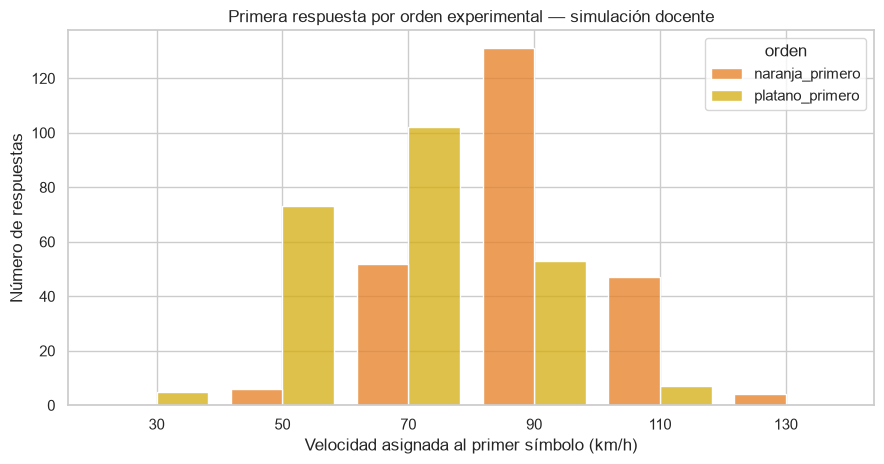

In [6]:
# CAMBIO SEGURO: sustituya solo estos dos colores y vuelva a ejecutar la celda.
COLOR_NARANJA = "#E67E22"
COLOR_PLATANO = "#D4AC0D"

paleta = {
    "naranja_primero": COLOR_NARANJA,
    "platano_primero": COLOR_PLATANO,
}

# QUÉ HACE: compara las distribuciones de la primera velocidad por grupo.
figura_histograma, eje_histograma = plt.subplots(figsize=(9, 4.8))
sns.histplot(
    data=analisis,
    x="velocidad_primera_kmh",
    hue="orden",
    binwidth=20,
    binrange=(20, 140),
    multiple="dodge",
    shrink=0.82,
    palette=paleta,
    ax=eje_histograma,
)
eje_histograma.set_xticks([30, 50, 70, 90, 110, 130])
eje_histograma.set_xlabel("Velocidad asignada al primer símbolo (km/h)")
eje_histograma.set_ylabel("Número de respuestas")
eje_histograma.set_title(
    "Primera respuesta por orden experimental — simulación docente"
)
figura_histograma.tight_layout()
display(
    figura_histograma,
    metadata={
        "image/png": {
            "alt": (
                "Histograma agrupado de la primera velocidad. El grupo que ve "
                "primero la naranja se concentra en categorías superiores al que "
                "ve primero el plátano; los datos son sintéticos."
            )
        }
    },
)
plt.close(figura_histograma)


<details>
<summary><strong>Microtarea opcional 2 — fuera del cronómetro: cambie el aspecto, no el dato</strong></summary>

Pruebe `COLOR_NARANJA = "#7B2CBF"` y vuelva a ejecutar la celda. El gráfico cambia;
las medias y el CSV permanecen iguales. Esta distinción importa: **estética no es
análisis**.
</details>


## 6. Leer un T-Test de Welch — minutos 21–24

El T-Test pregunta si la diferencia entre las dos medias es grande respecto a la
variabilidad de los grupos. El protocolo ya eligió el test y su dirección. Durante esta
clase no editaremos sus argumentos.

- `equal_var=False`: no obliga a que ambos grupos tengan la misma varianza;
- `alternative="greater"`: contrasta naranja primero **mayor que** plátano primero.

Solo lea dos salidas:

- `t`: diferencia expresada en unidades de error estándar;
- `p unilateral`: compatibilidad del resultado con la hipótesis nula bajo el modelo.

Un valor `p` no es la probabilidad de que la hipótesis nula sea cierta.


In [7]:
# QUÉ HACE: crea los dos vectores y ejecuta el Welch unilateral prerregistrado.
grupo_naranja = analisis.loc[
    analisis["orden"].eq("naranja_primero"),
    "velocidad_primera_kmh",
]
grupo_platano = analisis.loc[
    analisis["orden"].eq("platano_primero"),
    "velocidad_primera_kmh",
]

resultado_welch = stats.ttest_ind(
    grupo_naranja,
    grupo_platano,
    equal_var=False,
    alternative="greater",
)

diferencia_medias = grupo_naranja.mean() - grupo_platano.mean()
print(f"Diferencia de medias: {diferencia_medias:.2f} km/h")
print(f"Estadístico t: {resultado_welch.statistic:.2f}")
print(f"p unilateral: {resultado_welch.pvalue:.3e}")


Diferencia de medias: 20.58 km/h
Estadístico t: 13.96
p unilateral: 1.216e-37


**Lectura permitida:** dentro de esta simulación, la primera velocidad media es mayor
en el grupo que ve primero la naranja; `t ≈ 13,96` y `p < 0,001`.

**Lectura no permitida:** «la naranja es una señal rápida universal». Los datos fueron
generados para la docencia y no proceden de conductores observados.


## 7. Hacer una regresión y leer su tabla — minutos 24–29

Una regresión resume cómo cambia una variable cuando cambia otra. La fórmula:

```text
velocidad_naranja_kmh ~ velocidad_platano_kmh
    + C(orden, Treatment(reference="naranja_primero"))
```

se lee así: «describir la velocidad de la naranja mediante la velocidad del plátano y
el orden experimental». El símbolo `~` separa el resultado —izquierda— de las variables
explicativas —derecha—. `C(...)` indica que `orden` es una categoría, y fija
`naranja_primero` como referencia para que la comparación no dependa del orden
alfabético de las etiquetas.

Usamos errores robustos `HC3`. No necesita escribir esta especificación; sí debe poder
reconocer qué variable está a cada lado de `~`.


In [8]:
# QUÉ HACE: estima la regresión definida por la fórmula anterior.
modelo = smf.ols(
    "velocidad_naranja_kmh ~ velocidad_platano_kmh "
    "+ C(orden, Treatment(reference='naranja_primero'))",
    data=analisis,
).fit(cov_type="HC3")

# Mostramos solo las dos filas sustantivas; el intercepto es un parámetro técnico.
fila_orden = (
    "C(orden, Treatment(reference='naranja_primero'))"
    "[T.platano_primero]"
)
filas_lectura = ["velocidad_platano_kmh", fila_orden]
tabla_modelo = modelo.summary2().tables[1].loc[
    filas_lectura,
    ["Coef.", "[0.025", "0.975]", "P>|z|"],
].copy()

tabla_modelo.index = [
    "Velocidad del plátano",
    "Orden: plátano primero",
]
tabla_modelo.columns = [
    "coeficiente",
    "IC95_inferior",
    "IC95_superior",
    "p",
]
tabla_modelo[["coeficiente", "IC95_inferior", "IC95_superior"]] = (
    tabla_modelo[["coeficiente", "IC95_inferior", "IC95_superior"]]
    .round(3)
)
tabla_modelo["p"] = tabla_modelo["p"].map(
    lambda valor: "<0,001" if valor < 0.001 else f"{valor:.4f}".replace(".", ",")
)

tabla_modelo


,coeficiente,IC95_inferior,IC95_superior,p
Velocidad del plátano,0.46,0.40,0.52,"<0,001"
Orden: plátano primero,3.23,0.90,5.57,"0,0066"


### Cómo leer la tabla

Concéntrese en la fila `Velocidad del plátano`:

- **coeficiente ≈ 0,46:** en esta simulación, 20 km/h adicionales asignados al plátano
  se asocian con unos 9,15 km/h adicionales para la naranja, manteniendo fijo el orden;
- **IC 95 %:** intervalo compatible con el modelo y estos datos sintéticos;
- **p:** contraste del coeficiente frente a cero.

La fila `Orden: plátano primero` compara ese orden con `naranja_primero`, la referencia,
manteniendo fija la velocidad del plátano. La regresión describe covariación; no
demuestra que una respuesta cause la otra.


## Cierre — minuto 29–30

Ya puede leer la arquitectura mínima de un análisis:

```text
archivo → tabla → filtro → medias → gráfico → contraste → modelo → interpretación
```

| Expresión | Lectura mínima |
|---|---|
| `pd.read_csv(ruta)` | abre una tabla |
| `datos["columna"]` | selecciona una columna |
| `datos.loc[condición]` | conserva determinadas filas |
| `groupby("grupo").mean()` | calcula medias por grupo |
| `sns.histplot(...)` | representa una distribución |
| `color="#..."` | cambia estética, no resultados |
| `resultado ~ x + C(grupo)` | define una regresión |
| `modelo.summary2()` | produce la tabla del modelo |

### Tres tareas que ya debería poder hacer

1. Cambiar el redondeo de la tabla de medias.
2. Sustituir los dos colores del histograma.
3. Identificar en una fórmula cuál es el resultado y cuáles son los predictores.

El pipeline completo —validaciones de esquema, Regex, coordinación, permutaciones,
ajuste por comparaciones múltiples, hashes y bonificaciones— permanece en
`05_ANALISIS/scripts/analizar_datos.py`. Está disponible para auditoría, pero no forma
parte de esta introducción de treinta minutos.

> **Parece indicar que** saber leer código bien elegido ofrece más valor inicial que
> copiar veinte técnicas sin comprender qué objeto entra y qué salida produce.
